### Module import

In [1]:
import matplotlib
from equilibrator_api import ComponentContribution
from equilibrator_pathway import ThermodynamicModel
import seaborn as sns
import matplotlib.pyplot as plt
from equilibrator_pathway.ecm_model import EnzymeCostModel

sns.set_style("dark")

D:\work\python\anaconda\install\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\work\python\anaconda\install\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
comp_contrib = ComponentContribution()

In [3]:
pp = ThermodynamicModel.from_sbtab("Butanoic acid and butanol.tsv", comp_contrib=comp_contrib)
pp.update_standard_dgs()
pp.dg_confidence = 0.0  # 0.95

In [4]:
%%time
mdf_sol = pp.mdf_analysis()

Wall time: 215 ms


### Calculate the shadow prices of metabolites

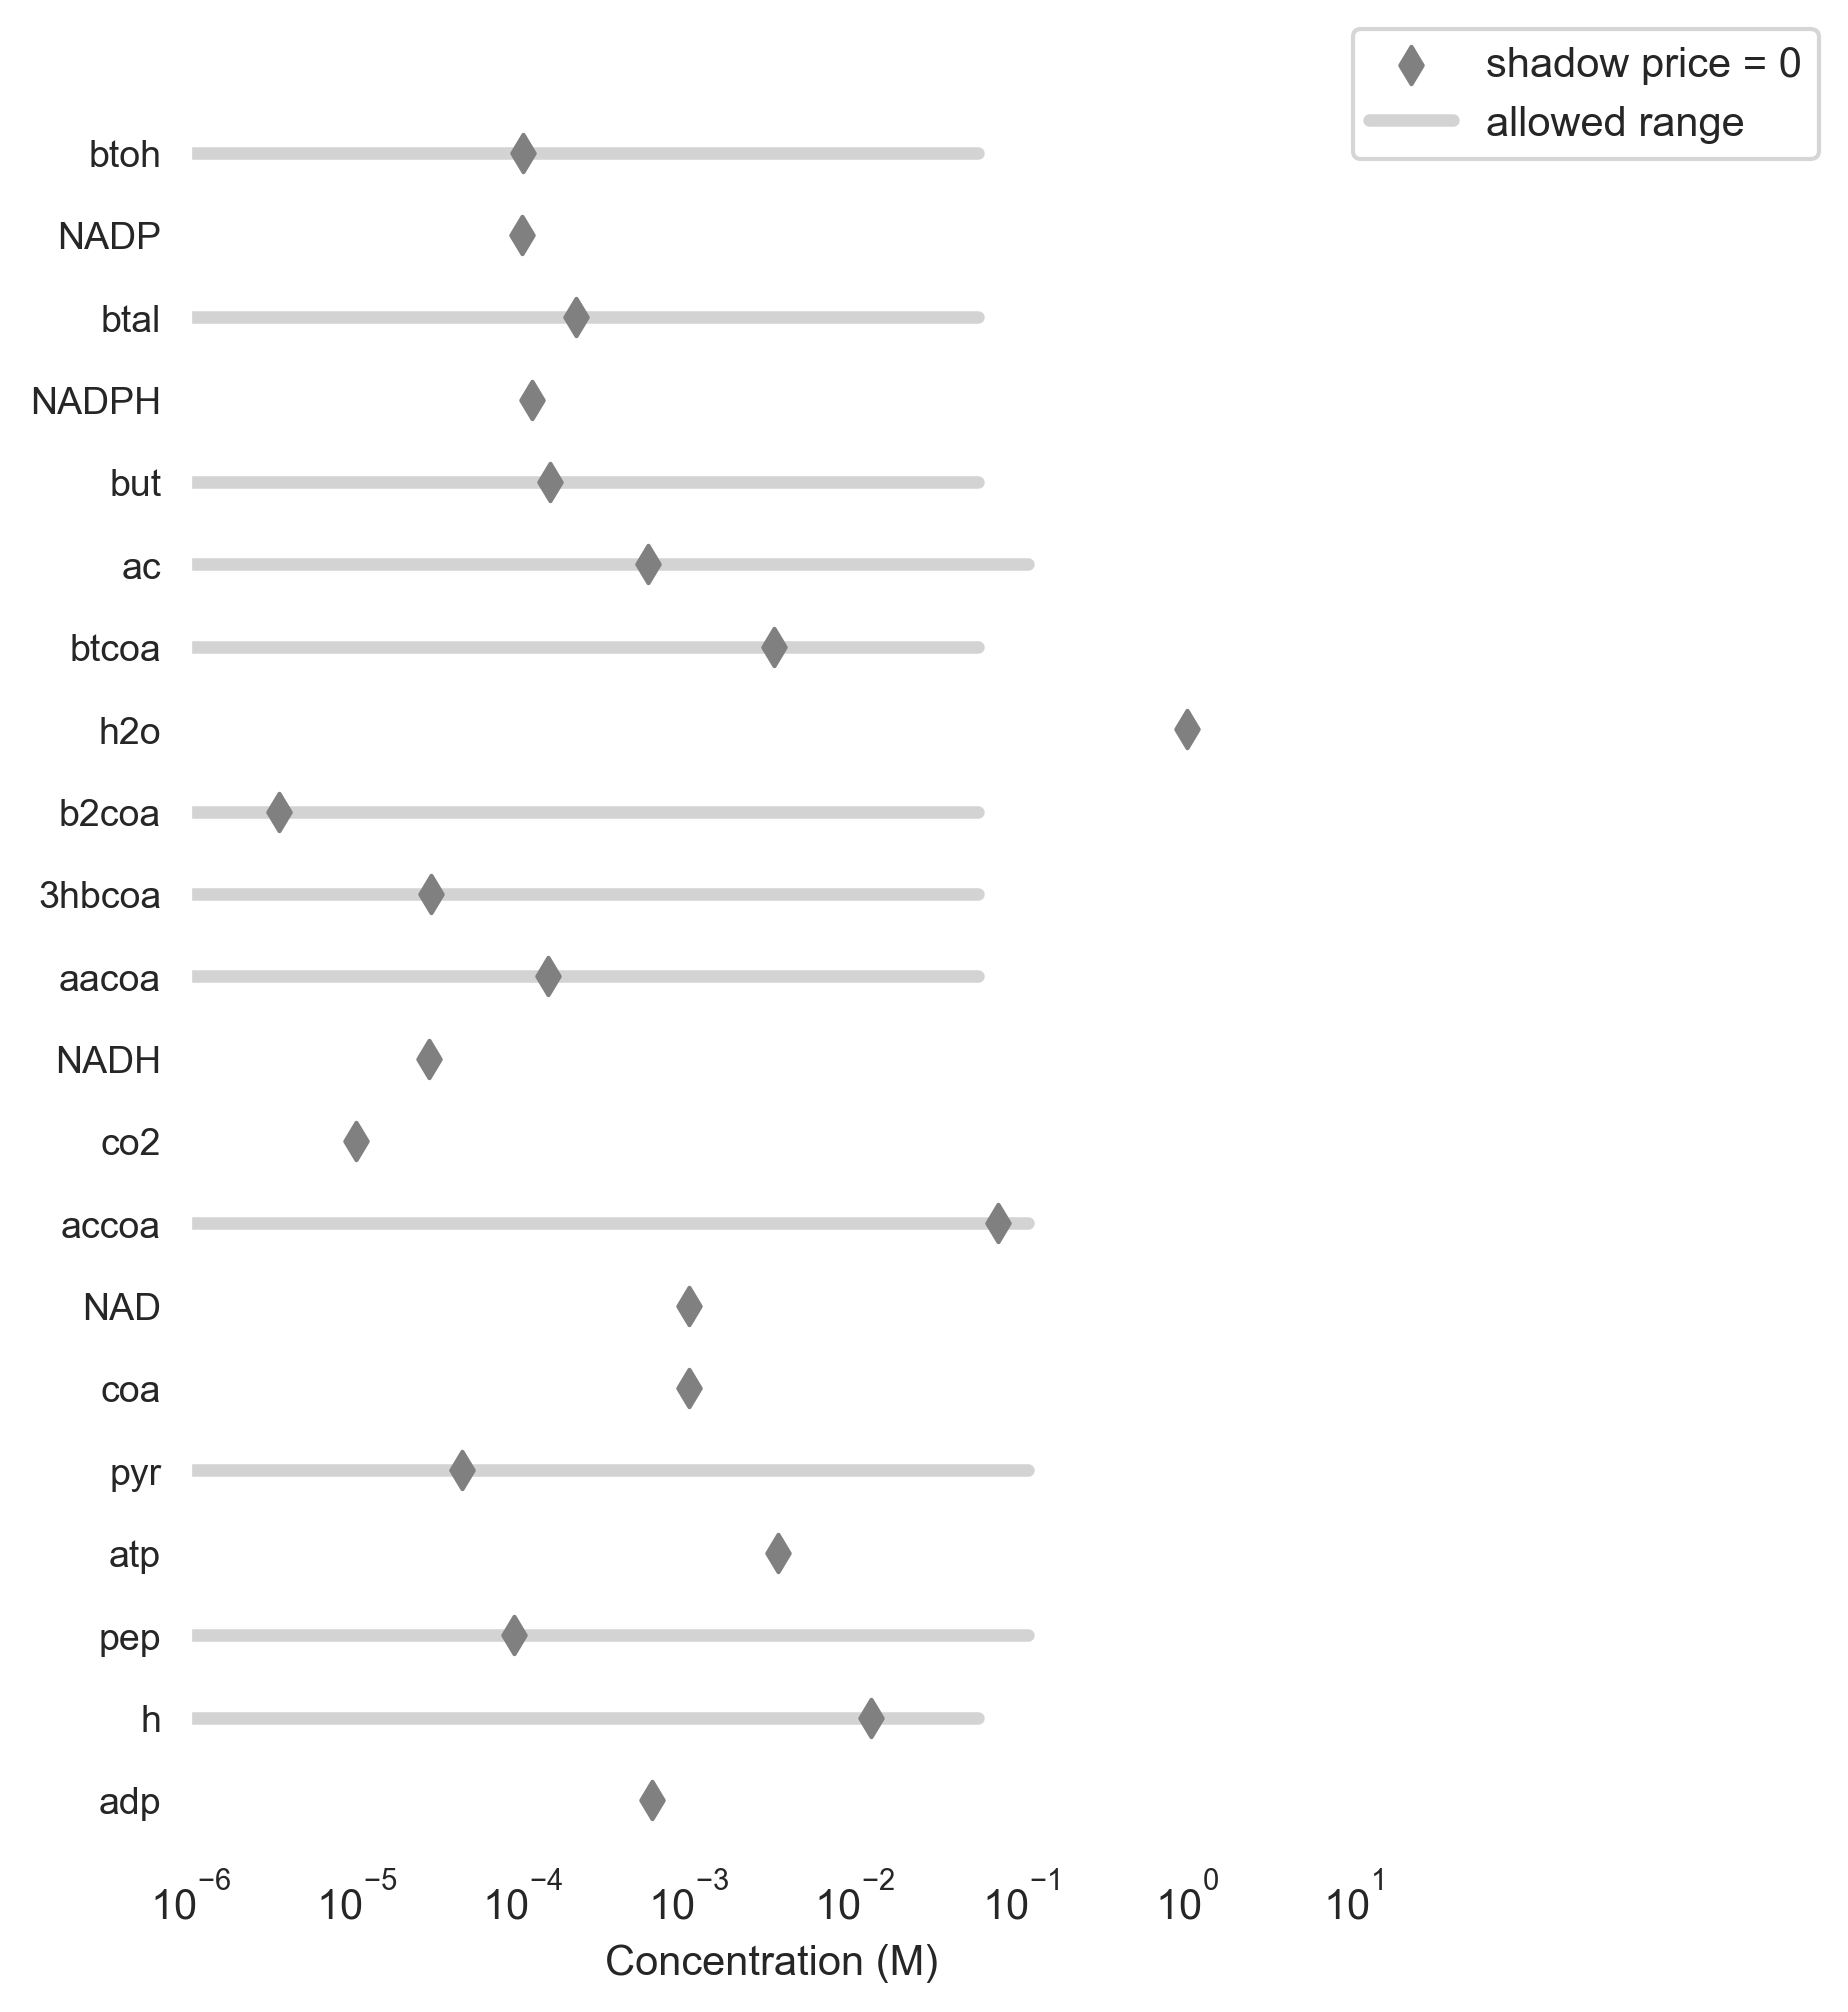

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8), dpi=300)
mdf_sol.plot_concentrations(ax=ax)
plt.xlim(10**-6,10**1)
ax.legend(loc='upper right',fontsize='small',facecolor='none')
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0, facecolor='white')
ax.axes.yaxis.grid(True, which="major")
ax.set_facecolor('none')
plt.savefig("shadow price_butanol.svg", bbox_inches = 'tight', dpi=300,format="svg")

### Calculate the MDF value of the biosynthesis pathway for the two strains

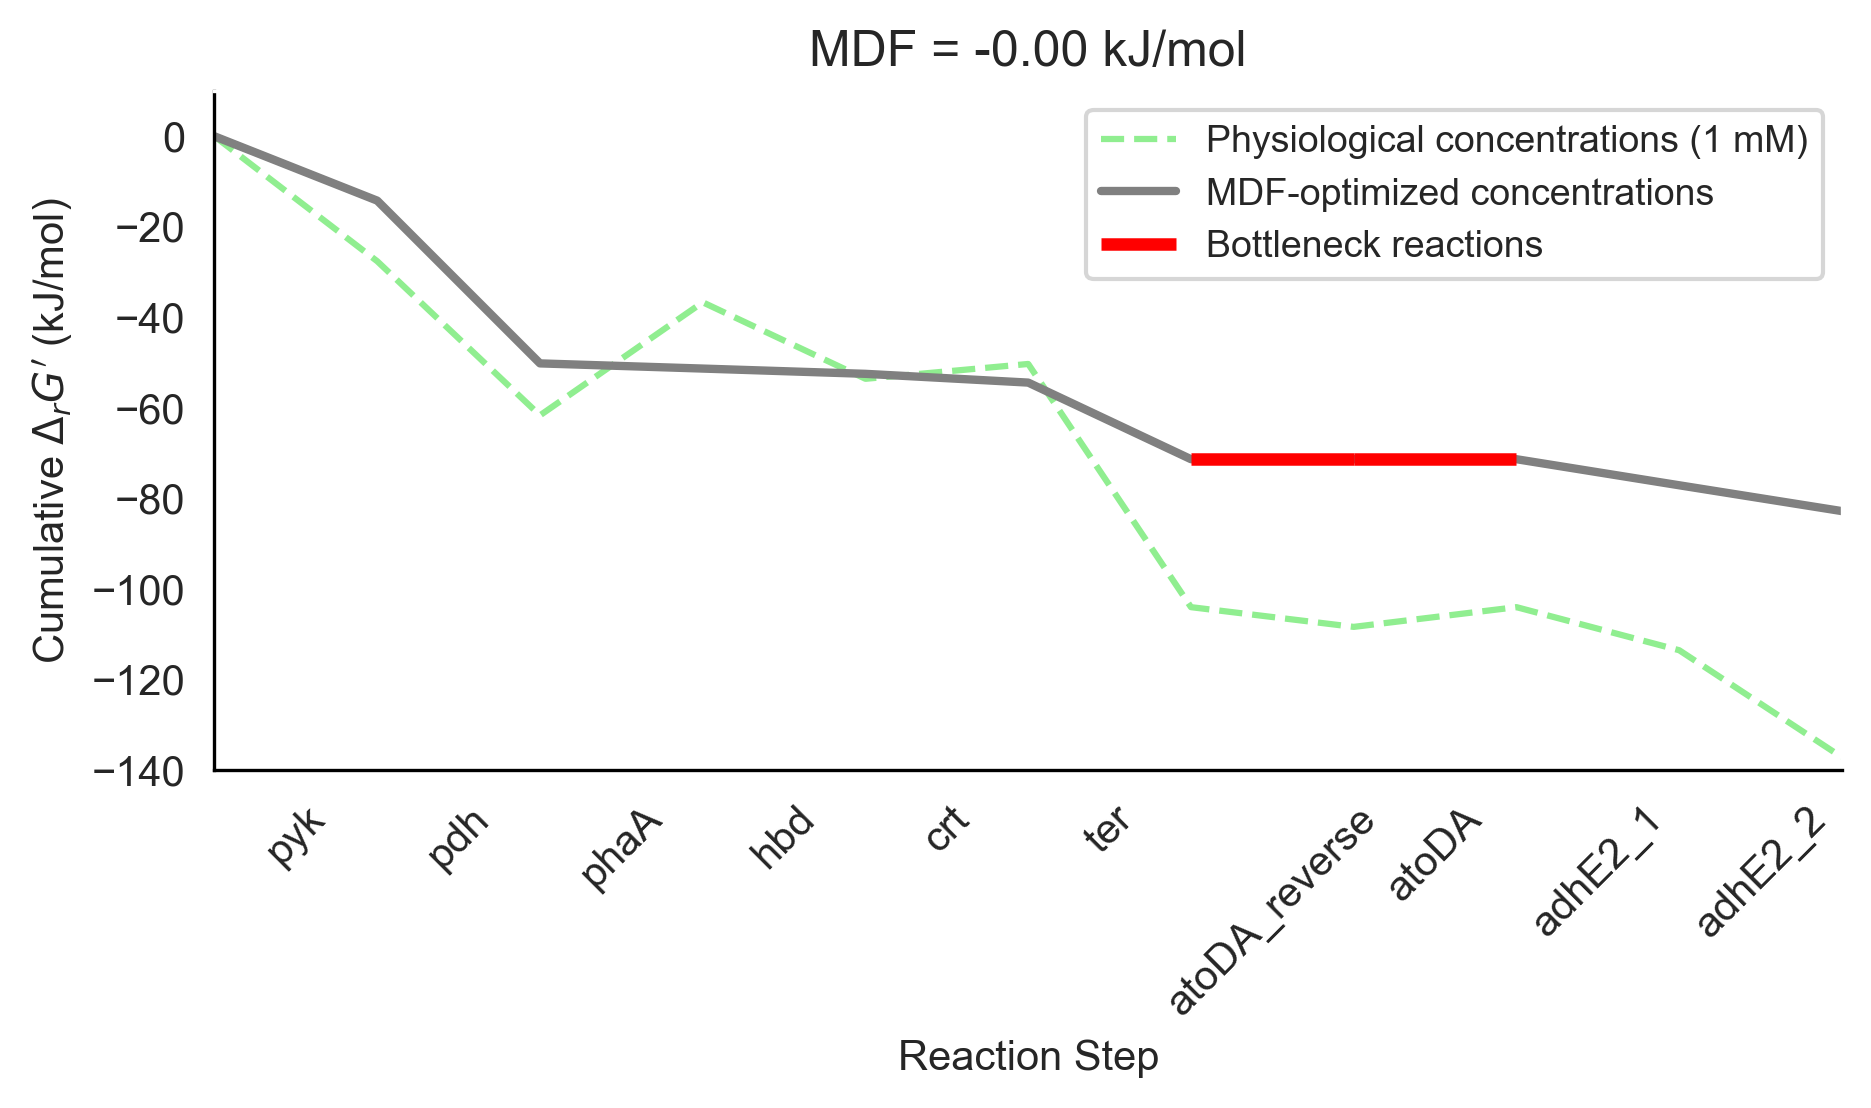

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3), dpi=300)
mdf_sol.plot_driving_forces(ax=ax)
plt.ylim(-140,10)
ax.legend(loc='upper right',fontsize=9,facecolor='none')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.axes.xaxis.grid(True, which="major")
ax.set_facecolor('none')
plt.savefig("MDF_butanol.svg", bbox_inches = 'tight', dpi=300,format="svg")

In [7]:
mdf_sol.reaction_df

,reaction_id,reaction_formula,flux,original_standard_dg_prime,standard_dg_prime,physiological_dg_prime,optimized_dg_prime,shadow_price
0,pyk,adp + h + pep = atp + pyr,0.0006 millimolar / second,-27.5833233583064 kilojoule / mole,-27.5833233583064 kilojoule / mole,-27.5833233583064 kilojoule / mole,-14.207014519357164 kilojoule / mole,0.0
1,pdh,NAD + coa + pyr = NADH + accoa + co2,0.0006 millimolar / second,-34.02434772279025 kilojoule / mole,-34.02434772279025 kilojoule / mole,-34.02434772279025 kilojoule / mole,-35.92643669213836 kilojoule / mole,0.0
2,phaA,2 accoa = aacoa + coa,0.0006 millimolar / second,24.96121615861489 kilojoule / mole,24.96121615861489 kilojoule / mole,24.96121615861489 kilojoule / mole,-1.1428901761262686 kilojoule / mole,0.0
3,hbd,NADH + aacoa + h = 3hbcoa + NAD,0.0006 millimolar / second,-16.889474845328778 kilojoule / mole,-16.889474845328778 kilojoule / mole,-16.889474845328778 kilojoule / mole,-1.1620243382790587 kilojoule / mole,0.0
4,crt,3hbcoa = b2coa + h2o,0.0006 millimolar / second,3.2759179325111774 kilojoule / mole,3.2759179325111774 kilojoule / mole,3.2759179325111774 kilojoule / mole,-1.934849956605892 kilojoule / mole,0.0
5,ter,NADH + b2coa + h = NAD + btcoa,0.0006 millimolar / second,-53.68402969688259 kilojoule / mole,-53.68402969688259 kilojoule / mole,-53.68402969688259 kilojoule / mole,-16.912467415746306 kilojoule / mole,0.0
6,atoDA_reverse,ac + btcoa = accoa + but,0.0006 millimolar / second,-4.355200403128094 kilojoule / mole,-4.355200403128094 kilojoule / mole,-4.355200403128094 kilojoule / mole,-5.990319351667495e-11 kilojoule / mole,0.5
7,atoDA,accoa + but = ac + btcoa,0.0006 millimolar / second,4.355200403128094 kilojoule / mole,4.355200403128094 kilojoule / mole,4.355200403128094 kilojoule / mole,5.990319351667495e-11 kilojoule / mole,0.5
8,adhE2_1,NADPH + btcoa + h = NADP + btal + coa,0.0006 millimolar / second,7.602532486786231 kilojoule / mole,7.602532486786231 kilojoule / mole,-9.512305047934802 kilojoule / mole,-5.755440765378751 kilojoule / mole,0.0
9,adhE2_2,NADH + btal + h = NAD + btoh,0.0006 millimolar / second,-23.633601377682055 kilojoule / mole,-23.633601377682055 kilojoule / mole,-23.633601377682055 kilojoule / mole,-5.703961001098744 kilojoule / mole,0.0
